# Named Entity Recognition (NER)

## 1. What is Named Entity Recognition?

**Named Entity Recognition (NER)** is an NLP technique used to identify important **real-world entities** in text.

It finds things such as:

- People
- Organizations
- Locations
- Dates
- Money
- Companies
- Countries
- Products

Example:

```text
"Naruto was born in Japan."
```

NER can identify:

```text
Naruto → PERSON
Japan  → GPE
```

---

# 2. Why Do We Use NER?

NER helps a computer understand **who, what, and where** is being discussed in a piece of text.

For example:

```text
"Elon Musk founded SpaceX in the United States."
```

NER can identify:

```text
Elon Musk        → PERSON
SpaceX           → ORGANIZATION
United States    → GPE
```

This is useful for:

- Search engines
- Chatbots
- Information extraction
- News analysis
- Question answering
- Document analysis
- Recommendation systems
- Resume parsing
- Financial analysis
- Healthcare NLP

---

# 3. POS Tagging vs NER

These two concepts are different.

## POS Tagging

POS tagging identifies the **grammatical role** of a word.

```text
"Ali is running."

Ali      → NNP
is       → VBZ
running  → VBG
```

It tells us:

```text
Ali      = Proper noun
is       = Verb
running  = Verb
```

## NER

NER identifies whether a word or group of words represents a **real-world entity**.

```text
"Ali lives in Pakistan."

Ali       → PERSON
Pakistan  → GPE
```

---

# 4. Example

Sentence:

```text
"Microsoft was founded by Bill Gates in the United States."
```

NER might identify:

```text
Microsoft       → ORGANIZATION
Bill Gates      → PERSON
United States   → GPE
```

Notice that an entity can contain **multiple words**.

```text
Bill Gates
```

is one entity, not two separate entities.

---

# 5. NER Using NLTK

NLTK provides:

```python
nltk.ne_chunk()
```

Basic pipeline:

```text
Text
 ↓
Tokenization
 ↓
POS Tagging
 ↓
Named Entity Recognition
 ↓
Entities
```

---

# 6. Basic Syntax

```python
import nltk

words = nltk.word_tokenize(sentence)

pos_tags = nltk.pos_tag(words)

entities = nltk.ne_chunk(pos_tags)

print(entities)
```

---

# 7. Download Required NLTK Resources

For current NLTK versions, you may need:

```python
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("maxent_ne_chunker_tab")
nltk.download("words")
```

---

# 8. Simple Example

```python
import nltk

sentence = "Barack Obama was born in Hawaii."

words = nltk.word_tokenize(sentence)

pos_tags = nltk.pos_tag(words)

entities = nltk.ne_chunk(pos_tags)

print(entities)
```

You may see something similar to:

```text
(S
  (PERSON Barack/NNP Obama/NNP)
  was/VBD
  born/VBN
  in/IN
  (GPE Hawaii/NNP)
  ./.)
```

The important part is:

```text
(PERSON Barack Obama)
(GPE Hawaii)
```

---

# 9. Understanding the Output

Consider:

```text
(PERSON Barack Obama)
```

This means:

```text
Entity:
    Barack Obama

Entity Type:
    PERSON
```

And:

```text
(GPE Hawaii)
```

means:

```text
Entity:
    Hawaii

Entity Type:
    GPE
```

---

# 10. Common NER Tags

Different NLP libraries can use different entity labels.

Some common NLTK labels are:

| Tag | Meaning | Example |
|---|---|---|
| PERSON | Person | Barack Obama |
| ORGANIZATION | Organization | Google |
| GPE | Geopolitical Entity | Pakistan |
| LOCATION | Location | Mount Everest |
| FACILITY | Facility | Pentagon |
| DATE | Date | Monday |
| MONEY | Money | $500 |
| PERCENT | Percentage | 50% |
| TIME | Time | 10 AM |
| PRODUCT | Product | iPhone |

---

# 11. PERSON

Identifies people.

Example:

```text
"Naruto is a ninja."
```

NER:

```text
Naruto → PERSON
```

Another example:

```text
"Bill Gates founded Microsoft."
```

```text
Bill Gates → PERSON
```

---

# 12. ORGANIZATION

Identifies organizations.

Example:

```text
"Microsoft released a new product."
```

```text
Microsoft → ORGANIZATION
```

Other examples:

```text
Google
NASA
United Nations
```

---

# 13. GPE

GPE means:

**Geopolitical Entity**

It usually represents countries, cities, states, etc.

Example:

```text
"Ali lives in Pakistan."
```

```text
Pakistan → GPE
```

Another example:

```text
"She moved to London."
```

```text
London → GPE
```

---

# 14. LOCATION

Identifies geographical locations that aren't necessarily geopolitical entities.

Example:

```text
"Mount Everest is very high."
```

Possible entity:

```text
Mount Everest → LOCATION
```

---

# 15. NER and Multiple Words

NER can identify an entire phrase as one entity.

Example:

```text
"United States"
```

Instead of:

```text
United → GPE
States  → GPE
```

NER can identify:

```text
United States → GPE
```

Similarly:

```text
Bill Gates → PERSON
New York → GPE
United Nations → ORGANIZATION
```

---

# 16. NER Pipeline

The basic NLTK process is:

```text
Sentence
    ↓
Tokenization
    ↓
Words
    ↓
POS Tagging
    ↓
Named Entity Chunking
    ↓
Named Entities
```

Example:

```text
"Bill Gates founded Microsoft."

          ↓

["Bill", "Gates", "founded", "Microsoft"]

          ↓

POS TAGGING

Bill       → NNP
Gates      → NNP
founded    → VBD
Microsoft  → NNP

          ↓

NER

Bill Gates → PERSON
Microsoft  → ORGANIZATION
```

---

# 17. Why POS Tagging Comes Before NER?

Traditional NLTK NER uses POS information as part of its entity-recognition process.

That's why we generally do:

```python
words = nltk.word_tokenize(sentence)

pos_tags = nltk.pos_tag(words)

entities = nltk.ne_chunk(pos_tags)
```

Rather than directly sending raw text to `ne_chunk()`.

---

# 18. NER with a Sentence

```python
import nltk

sentence = "Elon Musk founded SpaceX in California."

# Step 1: Tokenization
words = nltk.word_tokenize(sentence)

# Step 2: POS tagging
pos_tags = nltk.pos_tag(words)

# Step 3: Named Entity Recognition
entities = nltk.ne_chunk(pos_tags)

print(entities)
```

---

# 19. Extract Only Named Entities

`ne_chunk()` returns a tree.

If we want to extract only the entities:

```python
import nltk

sentence = "Elon Musk founded SpaceX in California."

words = nltk.word_tokenize(sentence)

pos_tags = nltk.pos_tag(words)

tree = nltk.ne_chunk(pos_tags)

for chunk in tree:
    if hasattr(chunk, "label"):
        print(chunk.label(), "→", " ".join(c[0] for c in chunk))
```

Possible output:

```text
PERSON → Elon Musk
ORGANIZATION → SpaceX
GPE → California
```

---

# 20. Another Example

```python
sentence = """
Muhammad Ali traveled from Pakistan to the United States
and visited Microsoft in Seattle.
"""

words = nltk.word_tokenize(sentence)

pos_tags = nltk.pos_tag(words)

tree = nltk.ne_chunk(pos_tags)

print(tree)
```

NER attempts to identify entities such as:

```text
Muhammad Ali      → PERSON
Pakistan          → GPE
United States     → GPE
Microsoft         → ORGANIZATION
Seattle           → GPE
```

---

# 21. NER vs Stop Words

Stop-word removal and NER have different purposes.

Stop words:

```text
the
is
a
and
of
```

NER:

```text
Ali → PERSON
Pakistan → GPE
Google → ORGANIZATION
```

### Important

For NER, **don't blindly remove stop words before entity recognition**.

Why?

Because some entity names can contain common words.

For example:

```text
The United States
```

or:

```text
The Who
```

Removing words before NER can potentially change the context.

---

# 22. NER vs Lemmatization

### Lemmatization

```text
running → run
studies → study
```

It changes a word into its base form.

### NER

```text
Naruto → PERSON
Japan → GPE
```

It identifies what type of real-world entity a word or phrase represents.

---

# 23. NER vs POS Tagging

```text
POS TAGGING
     ↓
"What grammatical role does this word have?"

NER
     ↓
"Does this word/phrase represent an important real-world entity?"
```

Example:

```text
"Ali lives in Pakistan."
```

POS:

```text
Ali       → NNP
lives     → VBZ
in        → IN
Pakistan  → NNP
```

NER:

```text
Ali       → PERSON
Pakistan  → GPE
```

---

# 24. Important Limitation

NLTK's `ne_chunk()` is a **basic traditional NER approach**.

For more advanced real-world NLP projects, you will often encounter libraries/models such as:

```text
spaCy
Hugging Face Transformers
BERT-based NER models
```

But understanding NLTK first is useful for learning the fundamental concept.

---

# Mental Model

```text
             RAW TEXT
                 ↓
           Tokenization
                 ↓
              Tokens
                 ↓
           POS Tagging
                 ↓
        Named Entity Recognition
                 ↓
      ┌──────────┼───────────┐
      ↓          ↓           ↓
    PERSON     GPE       ORGANIZATION
      ↓          ↓           ↓
  Bill Gates  Pakistan     Microsoft
```

# Key Point

> **Named Entity Recognition (NER) identifies real-world entities such as people, organizations, locations, countries, dates, and money in text and assigns them appropriate entity labels.**

In [4]:
import  nltk 
nltk.download("maxent_ne_chunker_tab")
nltk.download("words")

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /home/aizen/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /home/aizen/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


True

In [2]:
nltk.word_tokenize("Naruto was Born in Japan")

['Naruto', 'was', 'Born', 'in', 'Japan']

In [5]:
words = nltk.word_tokenize("Naruto was Born in Japan")

pos_tags = nltk.pos_tag(words)

entities = nltk.ne_chunk(pos_tags)

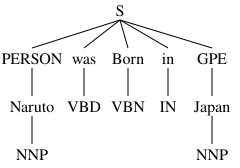

In [7]:
entities